In [10]:
!pip install xlrd

# 0 - Imports

In [119]:
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import ParameterGrid
from collections import defaultdict

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 1 - Data collection

## 1.1 - Extract and download data to folder

In [3]:
urls = [
    'http://tennis-data.co.uk/2000/2000.xls', 
    #'http://tennis-data.co.uk/2001/2001.xls', 
    'http://tennis-data.co.uk/2002/2002.xls',
    'http://tennis-data.co.uk/2003/2003.xls', 
    'http://tennis-data.co.uk/2004/2004.xls',
    'http://tennis-data.co.uk/2005/2005.xls', 
    'http://tennis-data.co.uk/2006/2006.xls',
    'http://tennis-data.co.uk/2007/2007.xls', 
    #'http://tennis-data.co.uk/2008/2008.zip', 
    'http://tennis-data.co.uk/2009/2009.xls', 
    'http://tennis-data.co.uk/2010/2010.xls',
    'http://tennis-data.co.uk/2011/2011.xls', 
    'http://tennis-data.co.uk/2012/2012.xls',
    'http://tennis-data.co.uk/2013/2013.xlsx', 
    'http://tennis-data.co.uk/2014/2014.xlsx',
    'http://tennis-data.co.uk/2015/2015.xlsx', 
    'http://tennis-data.co.uk/2016/2016.xlsx', 
    'http://tennis-data.co.uk/2017/2017.xlsx', 
    'http://tennis-data.co.uk/2018/2018.xlsx',
    'http://tennis-data.co.uk/2019/2019.xlsx', 
    'http://tennis-data.co.uk/2020/2020.xlsx',
    'http://tennis-data.co.uk/2021/2021.xlsx', 
    'http://tennis-data.co.uk/2022/2022.xlsx',
    'http://tennis-data.co.uk/2023/2023.xlsx',
    'http://tennis-data.co.uk/2024/2024.xlsx',
    'http://tennis-data.co.uk/2025/2025.xlsx',
    'http://tennis-data.co.uk/2026/2026.xlsx'
]

# Folder to save files
save_folder = "datasets"
os.makedirs(save_folder, exist_ok=True)

for url in urls:
    filename = url.split("/")[-1]
    filepath = os.path.join(save_folder, filename)
    
    print(f"Downloading {filename}...")
    
    response = requests.get(url)
    with open(filepath, "wb") as f:
        f.write(response.content)

## 1.2 - Read data and insert to dataframe

In [4]:
folder_path = "datasets"

# Dictionary to save dataframes
dfs = {}

for file in os.listdir(folder_path):
    filepath = os.path.join(folder_path, file)
    if file.endswith(".xlsx"):
        df = pd.read_excel(filepath)
        
    elif file.endswith(".xls"):
        df = pd.read_excel(filepath, engine="xlrd")
        
    else:
        continue
    
    # Use filename as key
    key = os.path.splitext(file)[0]
    dfs[key] = df
    
    print(f"Loaded {file} → key: '{key}', shape: {df.shape}")

print("\nTotal datasets loaded:", len(dfs))

Loaded 2000.xls → key: '2000', shape: (2963, 26)
Loaded 2001.xls → key: '2001', shape: (2963, 34)
Loaded 2002.xls → key: '2002', shape: (2854, 36)
Loaded 2003.xls → key: '2003', shape: (2861, 36)
Loaded 2004.xls → key: '2004', shape: (2877, 36)
Loaded 2005.xls → key: '2005', shape: (2909, 38)
Loaded 2006.xls → key: '2006', shape: (2909, 38)
Loaded 2007.xls → key: '2007', shape: (2806, 38)
Loaded 2008.xls → key: '2008', shape: (2707, 38)
Loaded 2009.xls → key: '2009', shape: (2731, 38)
Loaded 2010.xls → key: '2010', shape: (2679, 42)
Loaded 2011.xls → key: '2011', shape: (2675, 42)
Loaded 2012.xls → key: '2012', shape: (2607, 42)


C:\Users\brand\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


Loaded 2013.xlsx → key: '2013', shape: (2631, 42)


C:\Users\brand\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


Loaded 2014.xlsx → key: '2014', shape: (2600, 42)


C:\Users\brand\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


Loaded 2015.xlsx → key: '2015', shape: (2630, 40)


C:\Users\brand\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


Loaded 2016.xlsx → key: '2016', shape: (2626, 40)
Loaded 2017.xlsx → key: '2017', shape: (2633, 40)
Loaded 2018.xlsx → key: '2018', shape: (2637, 40)
Loaded 2019.xlsx → key: '2019', shape: (2610, 36)
Loaded 2020.xlsx → key: '2020', shape: (1267, 36)
Loaded 2021.xlsx → key: '2021', shape: (2489, 36)
Loaded 2022.xlsx → key: '2022', shape: (2632, 36)
Loaded 2023.xlsx → key: '2023', shape: (2703, 36)
Loaded 2024.xlsx → key: '2024', shape: (2703, 36)
Loaded 2025.xlsx → key: '2025', shape: (2644, 38)
Loaded 2026.xlsx → key: '2026', shape: (859, 38)

Total datasets loaded: 27


## 1.3 - Data cleaning

In [5]:
# Get sets of column names for each year/df
column_sets = [set(df.columns) for df in dfs.values()]

# Find columns present in all dfs
common_columns = set.intersection(*column_sets)

print(f"Columns present in all datasets ({len(common_columns)}):")
print(common_columns)

Columns present in all datasets (26):
{'Lsets', 'Location', 'L5', 'WRank', 'Date', 'Series', 'L3', 'W4', 'Loser', 'Comment', 'ATP', 'Court', 'L4', 'Best of', 'L2', 'LRank', 'Winner', 'W1', 'L1', 'Wsets', 'Round', 'W3', 'W2', 'Tournament', 'Surface', 'W5'}


In [6]:
for year, df in dfs.items():
    unique_cols = set(df.columns) - common_columns
    if unique_cols:
        print(f"Columns only in {year}: {unique_cols}")

Columns only in 2001: {'IWL', 'CBL', 'SBW', 'SBL', 'CBW', 'GBW', 'IWW', 'GBL'}
Columns only in 2002: {'IWL', 'CBL', 'SBW', 'B365W', 'SBL', 'CBW', 'GBW', 'IWW', 'B365L', 'GBL'}
Columns only in 2003: {'IWL', 'B&WL', 'CBL', 'B&WW', 'SBW', 'B365W', 'SBL', 'CBW', 'IWW', 'B365L'}
Columns only in 2004: {'PSW', 'IWL', 'EXL', 'CBL', 'B365W', 'CBW', 'EXW', 'IWW', 'B365L', 'PSL'}
Columns only in 2005: {'PSW', 'IWL', 'LPts', 'EXL', 'CBL', 'B365W', 'CBW', 'EXW', 'IWW', 'B365L', 'PSL', 'WPts'}
Columns only in 2006: {'PSW', 'LPts', 'EXL', 'CBL', 'UBL', 'B365W', 'UBW', 'CBW', 'EXW', 'B365L', 'PSL', 'WPts'}
Columns only in 2007: {'PSW', 'LPts', 'EXL', 'CBL', 'UBL', 'B365W', 'UBW', 'CBW', 'EXW', 'B365L', 'PSL', 'WPts'}
Columns only in 2008: {'PSW', 'LPts', 'EXL', 'UBL', 'B365W', 'UBW', 'EXW', 'B365L', 'PSL', 'LBW', 'WPts', 'LBL'}
Columns only in 2009: {'LPts', 'EXL', 'UBL', 'UBW', 'B365W', 'EXW', 'SJL', 'B365L', 'LBW', 'WPts', 'LBL', 'SJW'}
Columns only in 2010: {'PSW', 'LPts', 'EXL', 'B365W', 'MaxW', '

### 1.3.1 - Drop 2000-2004, 2026 dataframes

In [7]:
years_to_drop = ['2000','2001', '2002', '2003', '2004', '2026']

for year in years_to_drop:
    if year in dfs:
        del dfs[year]
    else:
        print(f"{year} not found in dfs")

### 1.3.2 - Drop bookmaker columns and keep used columns

In [8]:
# List of columns to keep
columns_to_keep = ['WPts', 'LPts', 'L5', 'Location', 'Winner', 'Date', 'ATP', 'Comment', 'W2', 'W5', 'L1', 'L3', 'Lsets', 'W4', 'Loser', 'Wsets', 'W1', 'LRank', 'WRank', 'Round', 'Surface', 'Best of', 'L2', 'W3', 'Tournament', 'Series', 'L4', 'Court']  

# Drop bookmaker columns across all DataFrames
for key, df in dfs.items():
    # Keep only the columns that exist in both the DataFrame and kept-columns list
    keep_cols = [col for col in df.columns if col in columns_to_keep]
    dfs[key] = df[keep_cols].copy()  # assign back a clean copy
    print(f"{key}: kept columns {dfs[key].columns.tolist()}")

2005: kept columns ['ATP', 'Location', 'Tournament', 'Date', 'Series', 'Court', 'Surface', 'Round', 'Best of', 'Winner', 'Loser', 'WRank', 'LRank', 'WPts', 'LPts', 'W1', 'L1', 'W2', 'L2', 'W3', 'L3', 'W4', 'L4', 'W5', 'L5', 'Wsets', 'Lsets', 'Comment']
2006: kept columns ['ATP', 'Location', 'Tournament', 'Date', 'Series', 'Court', 'Surface', 'Round', 'Best of', 'Winner', 'Loser', 'WRank', 'LRank', 'WPts', 'LPts', 'W1', 'L1', 'W2', 'L2', 'W3', 'L3', 'W4', 'L4', 'W5', 'L5', 'Wsets', 'Lsets', 'Comment']
2007: kept columns ['ATP', 'Location', 'Tournament', 'Date', 'Series', 'Court', 'Surface', 'Round', 'Best of', 'Winner', 'Loser', 'WRank', 'LRank', 'WPts', 'LPts', 'W1', 'L1', 'W2', 'L2', 'W3', 'L3', 'W4', 'L4', 'W5', 'L5', 'Wsets', 'Lsets', 'Comment']
2008: kept columns ['ATP', 'Location', 'Tournament', 'Date', 'Series', 'Court', 'Surface', 'Round', 'Best of', 'Winner', 'Loser', 'WRank', 'LRank', 'WPts', 'LPts', 'W1', 'L1', 'W2', 'L2', 'W3', 'L3', 'W4', 'L4', 'W5', 'L5', 'Wsets', 'Lsets',

### 1.3.3 - Rows and columns inspection

In [9]:
total_rows = 0
for year, df in dfs.items():
    print(f"\n--- {year} ---")
    # number of rows
    n_rows = int(df.shape[0])
    total_rows += n_rows
    # number of columns
    n_cols = df.shape[1]
    print(f"Rows: {n_rows}, Columns: {n_cols}")
print("Total rows:",total_rows)


--- 2005 ---
Rows: 2909, Columns: 28

--- 2006 ---
Rows: 2909, Columns: 28

--- 2007 ---
Rows: 2806, Columns: 28

--- 2008 ---
Rows: 2707, Columns: 28

--- 2009 ---
Rows: 2731, Columns: 28

--- 2010 ---
Rows: 2679, Columns: 28

--- 2011 ---
Rows: 2675, Columns: 28

--- 2012 ---
Rows: 2607, Columns: 28

--- 2013 ---
Rows: 2631, Columns: 28

--- 2014 ---
Rows: 2600, Columns: 28

--- 2015 ---
Rows: 2630, Columns: 28

--- 2016 ---
Rows: 2626, Columns: 28

--- 2017 ---
Rows: 2633, Columns: 28

--- 2018 ---
Rows: 2637, Columns: 28

--- 2019 ---
Rows: 2610, Columns: 28

--- 2020 ---
Rows: 1267, Columns: 28

--- 2021 ---
Rows: 2489, Columns: 28

--- 2022 ---
Rows: 2632, Columns: 28

--- 2023 ---
Rows: 2703, Columns: 28

--- 2024 ---
Rows: 2703, Columns: 28

--- 2025 ---
Rows: 2644, Columns: 28
Total rows: 54828


### 1.3.4 - Value checking

In [10]:
for year, df in dfs.items():
    print(f"\n--- {year} ---")
    
    # Total number of rows
    n_rows = df.shape[0]
    n_cols = df.shape[1]
    print(f"Rows: {n_rows}, Columns: {n_cols}")
    
    # Check missing / null values per column
    missing = df.isnull().sum()
    print("Missing values per column:")
    print(missing)


--- 2005 ---
Rows: 2909, Columns: 28
Missing values per column:
ATP              0
Location         0
Tournament       0
Date             0
Series           0
Court            0
Surface          0
Round            0
Best of          0
Winner           0
Loser            0
WRank            0
LRank            7
WPts          1676
LPts          1679
W1              11
L1              11
W2              29
L2              29
W3            1572
L3            1572
W4            2660
L4            2660
W5            2813
L5            2813
Wsets            9
Lsets            9
Comment          0
dtype: int64

--- 2006 ---
Rows: 2909, Columns: 28
Missing values per column:
ATP              0
Location         0
Tournament       0
Date             0
Series           0
Court            0
Surface          0
Round            0
Best of          0
Winner           0
Loser            0
WRank            2
LRank            7
WPts             2
LPts             8
W1              12
L1              12
W2

### 1.3.5 - Identify categorical and numerical columns, and unique categorical values

In [11]:
for year, df in dfs.items():
    print(f"\n--- {year} ---")
    
    # Separate column types
    numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    print(f"Numerical columns: {numerical_cols}")
    # for col in numerical_cols:
    #     unique_vals = df[col].unique()
    #     print(f"  {col}: {len(unique_vals)} unique values -> {unique_vals[:10]}{'...' if len(unique_vals) > 10 else ''}")
    
    print(f"\nCategorical columns: {categorical_cols}")
    for col in categorical_cols:
        unique_vals = df[col].unique()
        print(f"  {col}: {len(unique_vals)} unique values -> {unique_vals[:10]}{'...' if len(unique_vals) > 10 else ''}")


--- 2005 ---
Numerical columns: ['ATP', 'Best of', 'WRank', 'LRank', 'WPts', 'LPts', 'W1', 'L1', 'W4', 'L4', 'W5', 'L5', 'Wsets', 'Lsets']

Categorical columns: ['Location', 'Tournament', 'Series', 'Court', 'Surface', 'Round', 'Winner', 'Loser', 'W2', 'L2', 'W3', 'L3', 'Comment']
  Location: 66 unique values -> ['Adelaide' 'Chennai' 'Doha' 'Auckland' 'Sydney' 'Melbourne'
 'Delray Beach' 'Milan' 'Vina del Mar' 'Buenos Aires']...
  Tournament: 67 unique values -> ['Next Generation Hardcourts' 'TATA Open' 'Qatar Exxon Mobil Open'
 'Heineken Open' 'Medibank International' 'Australian Open'
 'International Championships' 'Internazionali di Lombardia'
 'Bellsouth Open' 'ATP Buenos Aires 2005']...
  Series: 5 unique values -> ['International' 'Grand Slam' 'International Gold' 'Masters' 'Masters Cup']
  Court: 2 unique values -> ['Outdoor' 'Indoor']
  Surface: 4 unique values -> ['Hard' 'Carpet' 'Clay' 'Grass']
  Round: 8 unique values -> ['1st Round' '2nd Round' 'Quarterfinals' 'Semifinals' 

### 1.3.6 - Merge into 1 dataframe

In [12]:
full_df = pd.concat(dfs.values(), ignore_index=True)

full_df["LRank"].describe()

count    54716.000000
mean        90.788709
std        120.979020
min          1.000000
25%         35.000000
50%         64.000000
75%        103.000000
max       4915.000000
Name: LRank, dtype: float64

### 1.3.7 - Dataset statistics

In [13]:
# Date range
print("Date range:", full_df["Date"].min(), "to", full_df["Date"].max())

Date range: 2005-01-03 00:00:00 to 2025-11-16 00:00:00


In [14]:
print(list(full_df.columns))

['ATP', 'Location', 'Tournament', 'Date', 'Series', 'Court', 'Surface', 'Round', 'Best of', 'Winner', 'Loser', 'WRank', 'LRank', 'WPts', 'LPts', 'W1', 'L1', 'W2', 'L2', 'W3', 'L3', 'W4', 'L4', 'W5', 'L5', 'Wsets', 'Lsets', 'Comment']


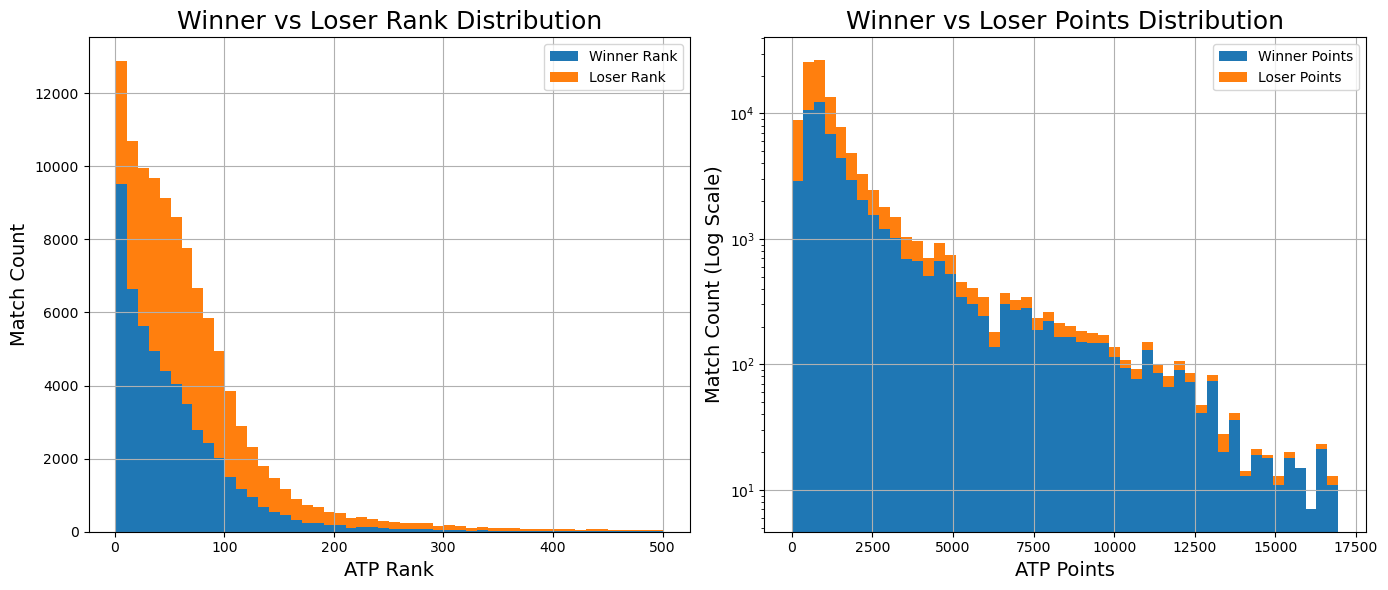

In [15]:
# Ensure numeric
full_df["WRank"] = pd.to_numeric(full_df["WRank"], errors="coerce")
full_df["LRank"] = pd.to_numeric(full_df["LRank"], errors="coerce")
full_df["WPts"] = pd.to_numeric(full_df["WPts"], errors="coerce")
full_df["LPts"] = pd.to_numeric(full_df["LPts"], errors="coerce")

# Clean data
df_rank = full_df.dropna(subset=["WRank", "LRank"]).copy()
df_rank = df_rank[(df_rank["WRank"] <= 500) & (df_rank["LRank"] <= 500)]

df_points = full_df.dropna(subset=["WPts", "LPts"]).copy()
df_points = df_points[(df_points["WPts"] > 0) & (df_points["LPts"] > 0)]

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Rank histogram
axes[0].hist([df_rank["WRank"], df_rank["LRank"]],
             bins=50,
             stacked=True,
             label=["Winner Rank", "Loser Rank"])
axes[0].set_title("Winner vs Loser Rank Distribution", fontsize=18)
axes[0].set_xlabel("ATP Rank", fontsize=14)
axes[0].set_ylabel("Match Count", fontsize=14)
axes[0].legend()
axes[0].grid(True)

# Points histogram
axes[1].hist([df_points["WPts"], df_points["LPts"]],
             bins=50,
             stacked=True,
             label=["Winner Points", "Loser Points"])
axes[1].set_yscale("log")
axes[1].set_title("Winner vs Loser Points Distribution", fontsize=18)
axes[1].set_xlabel("ATP Points", fontsize=14)
axes[1].set_ylabel("Match Count (Log Scale)", fontsize=14)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("tennis_plot_histogram.png", dpi=300)
plt.show()

Surface
Hard      30532
Clay      17253
Grass      6204
Carpet      839
Name: count, dtype: int64


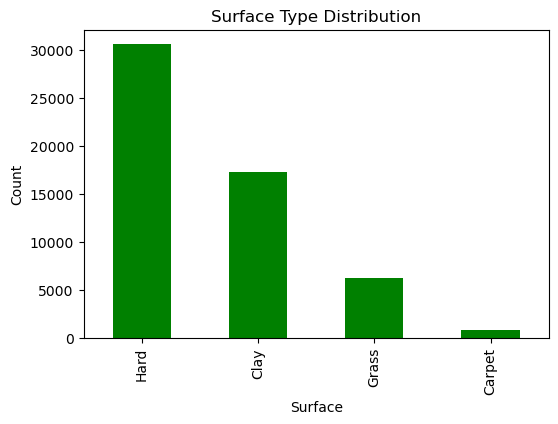

In [16]:
# Surface counts
surface_counts = full_df["Surface"].value_counts()
print(surface_counts)
plt.figure(figsize=(6,4))
surface_counts.plot(kind='bar', color='green')
plt.title("Surface Type Distribution")
plt.xlabel("Surface")
plt.ylabel("Count")
plt.show()

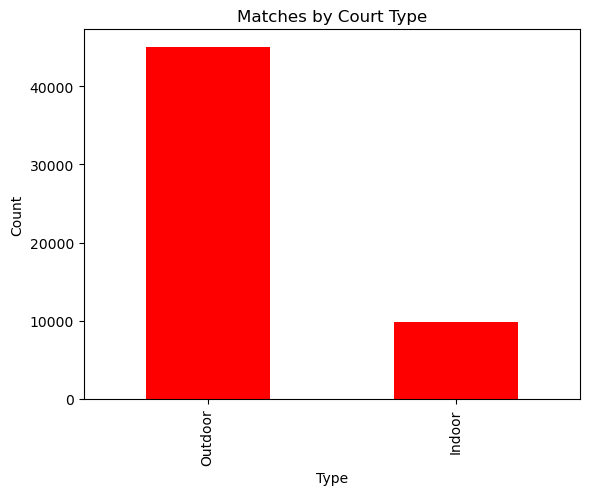

In [17]:
# Court type
indoor_counts = full_df["Court"].value_counts()
indoor_counts.plot(kind='bar', color="red")
plt.title("Matches by Court Type")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

In [18]:
# Unique player and tournaments
unique_players = set(full_df["Winner"]).union(set(full_df["Loser"]))
print("Unique players:", len(unique_players))
print("Unique tournaments:", full_df["Tournament"].nunique())

Unique players: 1486
Unique tournaments: 218


Best of
3.0    44257
5.0    10556
Name: count, dtype: int64


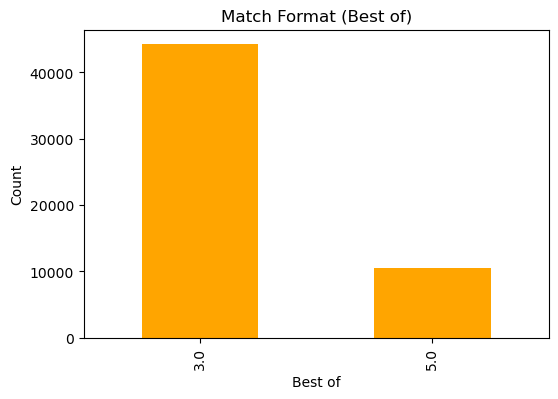

In [19]:
# Best of counts
best_of_counts = full_df["Best of"].value_counts()
print(best_of_counts)
plt.figure(figsize=(6,4))
best_of_counts.plot(kind='bar', color='orange')
plt.title("Match Format (Best of)")
plt.xlabel("Best of")
plt.ylabel("Count")
plt.show()


In [20]:
# Year counts
year_counts = full_df["Year"].value_counts().sort_index()
print(year_counts)
plt.figure(figsize=(10,5))
plt.plot(year_counts.index, year_counts.values, marker='o', linestyle='-', color='blue')
plt.title("Number of Matches per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True)
plt.xticks(year_counts.index, rotation=45)
plt.show()

KeyError: 'Year'

In [ ]:
# Prepare counts
year_counts = full_df["Year"].value_counts().sort_index()
best_of_counts = full_df["Best of"].value_counts()
surface_counts = full_df["Surface"].value_counts()
indoor_counts = full_df["Court"].value_counts()  

# Create a figure with 4 subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(18,10))

# Line chart for Year
axes[0, 0].plot(year_counts.index, year_counts.values, marker='o', linestyle='-', color='blue')
axes[0, 0].set_title("Matches per Year", fontsize=18)
axes[0, 0].set_xlabel("Year", fontsize=14)
axes[0, 0].set_ylabel("Count", fontsize=14)
axes[0, 0].grid(True)
axes[0, 0].set_xticks(year_counts.index)
axes[0, 0].tick_params(axis='x', rotation=45)

# Bar chart for Best of
axes[0, 1].bar(best_of_counts.index.astype(str), best_of_counts.values, color='orange')
axes[0, 1].set_title("Match Format (Best of)", fontsize=18)
axes[0, 1].set_xlabel("Best of", fontsize=14)
axes[0, 1].set_ylabel("Count", fontsize=14)

# Bar chart for Surface
axes[1, 0].bar(surface_counts.index, surface_counts.values, color='green')
axes[1, 0].set_title("Surface Type Distribution", fontsize=18)
axes[1, 0].set_xlabel("Surface", fontsize=14)
axes[1, 0].set_ylabel("Count", fontsize=14)

# Bar chart for Indoor/Outdoor
axes[1, 1].bar(indoor_counts.index, indoor_counts.values, color='purple')
axes[1, 1].set_title("Matches by Court Type", fontsize=18)
axes[1, 1].set_xlabel("Type", fontsize=14)
axes[1, 1].set_ylabel("Count", fontsize=14)

plt.tight_layout()
plt.savefig("tennis_plot_collage.png", dpi=300)
plt.show()

# 2 - Modeling

## 2.1 - Additional filtering and cleaning

In [128]:
df = full_df.copy()

# Convert Date to datetime and sort to preserve chronological order
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Filter out matches that weren't actually played (Walkovers, Retirements) 
# to ensure game/set stats are valid for Block 1 (Fatigue) calculations later
df = df[df['Comment'] == 'Completed']

# --- OPTIMIZATION: ELO RATINGS ---
def calculate_elo(df, k_factor=32):
    elo_dict = {}
    winner_elos = []
    loser_elos = []
    
    for idx, row in df.iterrows():
        w = row['Winner']
        l = row['Loser']
        
        # Get current Elo or default to 1500 for new players
        w_elo = elo_dict.get(w, 1500)
        l_elo = elo_dict.get(l, 1500)
        
        winner_elos.append(w_elo)
        loser_elos.append(l_elo)
        
        # Calculate expected win probability based on current Elo
        expected_w = 1 / (1 + 10 ** ((l_elo - w_elo) / 400))
        expected_l = 1 / (1 + 10 ** ((w_elo - l_elo) / 400))
        
        # Update dictionary with new Elo after match result
        elo_dict[w] = w_elo + k_factor * (1 - expected_w)
        elo_dict[l] = l_elo + k_factor * (0 - expected_l)
        
    df['Winner_Elo'] = winner_elos
    df['Loser_Elo'] = loser_elos
    return df

# Apply Elo calculations sequentially across the entire history
df = calculate_elo(df)

# Convert ranks and points to numeric, coercing errors (like 'NR' for Not Ranked) to NaN
for col in ['WRank', 'LRank', 'WPts', 'LPts']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

## 2.2 - Data structuring

In [129]:
# Convert winner/loser to Player A / Player B
np.random.seed(42)
# Create a boolean mask to randomly swap Winner/Loser 50% of the time
swap = np.random.rand(len(df)) > 0.5

# Assign players
df['Player_A'] = np.where(swap, df['Loser'], df['Winner'])
df['Player_B'] = np.where(swap, df['Winner'], df['Loser'])

# Target variable: 1 if Player A wins, 0 if Player A loses
df['Target_A_Win'] = np.where(swap, 0, 1)

# Map Ranks and Points based on the swap
df['Rank_A'] = np.where(swap, df['LRank'], df['WRank'])
df['Rank_B'] = np.where(swap, df['WRank'], df['LRank'])
df['Pts_A'] = np.where(swap, df['LPts'], df['WPts'])
df['Pts_B'] = np.where(swap, df['WPts'], df['LPts'])

## 2.3 - Block 0

### 0.1 - Feature engineering

#### 0.1.1 - Rank and points

In [130]:
# Point and rank differences from the perspective of Player A
df['Rank_Diff_A_B'] = df['Rank_A'] - df['Rank_B']
df['Pts_Diff_A_B'] = df['Pts_A'] - df['Pts_B']

#### 0.1.2 - ELO

In [131]:
# --- ELO DIFFERENTIAL ---
def calculate_elo(df, k_factor=32):
    elo_dict = {}          # global ELO: {player: rating}
    surface_elo_dict = {}  # surface ELO: {player: {surface: rating}}

    winner_elos, loser_elos = [], []
    winner_surface_elos, loser_surface_elos = [], []

    for idx, row in df.iterrows():
        w, l, surface = row['Winner'], row['Loser'], row['Surface']

        # --- Global ELO (unchanged) ---
        w_elo = elo_dict.get(w, 1500)
        l_elo = elo_dict.get(l, 1500)

        winner_elos.append(w_elo)
        loser_elos.append(l_elo)

        exp_w = 1 / (1 + 10 ** ((l_elo - w_elo) / 400))
        exp_l = 1 / (1 + 10 ** ((w_elo - l_elo) / 400))

        elo_dict[w] = w_elo + k_factor * (1 - exp_w)
        elo_dict[l] = l_elo + k_factor * (0 - exp_l)

        # --- Surface-specific ELO (new) ---
        w_srf = surface_elo_dict.setdefault(w, {}).get(surface, 1500)
        l_srf = surface_elo_dict.setdefault(l, {}).get(surface, 1500)

        winner_surface_elos.append(w_srf)
        loser_surface_elos.append(l_srf)

        exp_w_srf = 1 / (1 + 10 ** ((l_srf - w_srf) / 400))
        exp_l_srf = 1 / (1 + 10 ** ((w_srf - l_srf) / 400))

        surface_elo_dict[w][surface] = w_srf + k_factor * (1 - exp_w_srf)
        surface_elo_dict[l][surface] = l_srf + k_factor * (0 - exp_l_srf)

    df['Winner_Elo']         = winner_elos
    df['Loser_Elo']          = loser_elos
    df['Winner_Surface_Elo'] = winner_surface_elos
    df['Loser_Surface_Elo']  = loser_surface_elos
    return df

df = calculate_elo(df)

# --- ELO MAPPING ---
df['Elo_A'] = np.where(swap, df['Loser_Elo'], df['Winner_Elo'])
df['Elo_B'] = np.where(swap, df['Winner_Elo'], df['Loser_Elo'])
# --- ELO DIFFERENTIAL ---
df['Elo_Diff_A_B'] = df['Elo_A'] - df['Elo_B']

# --- SURFACE ELO MAPPING ---
df['Surface_Elo_A'] = np.where(swap, df['Loser_Surface_Elo'], df['Winner_Surface_Elo'])
df['Surface_Elo_B'] = np.where(swap, df['Winner_Surface_Elo'], df['Loser_Surface_Elo'])
# --- SURFACE ELO DIFFERENTIAL ---
df['Surface_Elo_Diff_A_B'] = df['Surface_Elo_A'] - df['Surface_Elo_B']

#### 0.1.3 - H2H

In [132]:
h2h_dict = defaultdict(lambda: defaultdict(int))  # h2h_dict[winner][loser] = prior wins

h2h_wins_A_list = []
h2h_wins_B_list = []

for _, row in df.iterrows():
    pA, pB = row['Player_A'], row['Player_B']

    # Read PRIOR wins before this match (no leakage)
    wins_A = h2h_dict[pA][pB]
    wins_B = h2h_dict[pB][pA]

    h2h_wins_A_list.append(wins_A)
    h2h_wins_B_list.append(wins_B)

    # Update AFTER recording pre-match state
    if row['Target_A_Win'] == 1:
        h2h_dict[pA][pB] += 1
    else:
        h2h_dict[pB][pA] += 1

df['H2H_Wins_A'] = h2h_wins_A_list
df['H2H_Wins_B'] = h2h_wins_B_list
df['H2H_Total']  = df['H2H_Wins_A'] + df['H2H_Wins_B']

# Raw differential (main signal: positive means A has beaten B more often)
df['H2H_Wins_Diff'] = df['H2H_Wins_A'] - df['H2H_Wins_B']

# Bayesian-smoothed win rate (handles first meetings gracefully; alpha=3 = mild prior toward 0.5)
alpha = 3
df['H2H_Win_Rate_A'] = (df['H2H_Wins_A'] + alpha) / (df['H2H_Total'] + 2 * alpha)

### 0.2 - Create final Block 0 differential features

In [133]:
# Create a clean dataframe for the baseline model
baseline_cols = ['Date', 'Tournament', 'Surface', 'Player_A', 'Player_B', 
                 'Rank_Diff_A_B', 'Pts_Diff_A_B', 'Elo_Diff_A_B',
                 'H2H_Wins_Diff', 'H2H_Win_Rate_A', 'H2H_Total',
                 'Target_A_Win', 'Surface_Elo_Diff_A_B']
model_df = df[baseline_cols].copy()

### 0.3 - Dataset split

In [134]:
# 1. Training Set (2005 to 2019)
train_set = model_df[model_df['Date'].dt.year <= 2019].copy()

# 2. Validation Set (2020 to 2023)
val_set = model_df[(model_df['Date'].dt.year >= 2020) & (model_df['Date'].dt.year <= 2023)].copy()

# 3. Testing Set (2024 to 2025)
test_set = model_df[model_df['Date'].dt.year >= 2024].copy()

# Verify the splits
print(f"Total Matches: {len(model_df)}")
print(f"Training Set: {len(train_set)} matches ({len(train_set)/len(model_df):.1%})")
print(f"Validation Set: {len(val_set)} matches ({len(val_set)/len(model_df):.1%})")
print(f"Testing Set: {len(test_set)} matches ({len(test_set)/len(model_df):.1%})")

Total Matches: 52779
Training Set: 38847 matches (73.6%)
Validation Set: 8808 matches (16.7%)
Testing Set: 5124 matches (9.7%)


## 2.4 - Block 1

### 1.1 - Calculate Total Games and Sets for each historical match

In [135]:
# Use original 'df' from before swapping A/B to calculate match stats
game_cols = ['W1', 'L1', 'W2', 'L2', 'W3', 'L3', 'W4', 'L4', 'W5', 'L5']
for col in game_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Sum across the row for total games
df['Total_Games'] = df[game_cols].sum(axis=1)

# Sum total sets
df['Total_Sets'] = pd.to_numeric(df['Wsets'], errors='coerce').fillna(0) + \
                   pd.to_numeric(df['Lsets'], errors='coerce').fillna(0)

### 1.2 - Create player history dataframe

In [136]:
winners = df[['Date', 'Winner', 'Total_Sets', 'Total_Games']].rename(columns={'Winner': 'Player'})
losers = df[['Date', 'Loser', 'Total_Sets', 'Total_Games']].rename(columns={'Loser': 'Player'})

# Combine, sort chronologically, and drop duplicates if a player played twice in one day
player_history = pd.concat([winners, losers]).sort_values(by=['Player', 'Date']).drop_duplicates(subset=['Player', 'Date'])

### 1.3 - Calculate rest days since last match

In [137]:
player_history['Days_Since_Last_Match'] = player_history.groupby('Player')['Date'].diff().dt.days

### 1.4 - Calculate 14-day rolling load

In [138]:
# --- NEW CODE: EWMA FATIGUE (Replaces old rolling window) ---
# Sort chronologically by player
player_history = player_history.sort_values(by=['Player', 'Date'])

# Calculate Exponential Moving Average (span=14 matches)
# .shift(1) ensures the EWMA only includes matches prior to the current row
ewma_metrics = player_history.groupby('Player')[['Total_Sets', 'Total_Games']].apply(
    lambda x: x.shift(1).ewm(span=14, adjust=False).mean()
).reset_index(level=0, drop=True)

player_history['Total_Sets_EWMA'] = ewma_metrics['Total_Sets']
player_history['Total_Games_EWMA'] = ewma_metrics['Total_Games']

# Fill NA for a player's very first match
player_history.fillna({'Total_Sets_EWMA': 0, 'Total_Games_EWMA': 0}, inplace=True)

# Create the final metrics dataframe
fatigue_metrics = player_history[['Date', 'Player', 'Days_Since_Last_Match', 'Total_Sets_EWMA', 'Total_Games_EWMA']].copy()

### 1.5 - Merge Block 1 features into model_df

In [139]:
# Merge for Player A
model_df = pd.merge(model_df, fatigue_metrics.add_suffix('_A'), 
                    left_on=['Date', 'Player_A'], right_on=['Date_A', 'Player_A'], how='left').drop(columns=['Date_A'])

# Merge for Player B
model_df = pd.merge(model_df, fatigue_metrics.add_suffix('_B'), 
                    left_on=['Date', 'Player_B'], right_on=['Date_B', 'Player_B'], how='left').drop(columns=['Date_B'])

### 1.6 - Create final Block 1 differential features

In [140]:
# --- NEW CODE: EWMA DIFFERENTIALS ---
model_df['Sets_Played_EWMA_Diff'] = model_df['Total_Sets_EWMA_A'] - model_df['Total_Sets_EWMA_B']
model_df['Games_Played_EWMA_Diff'] = model_df['Total_Games_EWMA_A'] - model_df['Total_Games_EWMA_B']
model_df['Rest_Days_Diff'] = model_df['Days_Since_Last_Match_A'] - model_df['Days_Since_Last_Match_B']

## 2.5 - Block 2

### 2.1 - Create a long DataFrame for Surface Performance

In [141]:
winners_sfc = df[['Date', 'Winner', 'Surface']].copy()
winners_sfc['Player'] = winners_sfc['Winner']
winners_sfc['Won'] = 1
winners_sfc = winners_sfc.drop(columns=['Winner'])

losers_sfc = df[['Date', 'Loser', 'Surface']].copy()
losers_sfc['Player'] = losers_sfc['Loser']
losers_sfc['Won'] = 0
losers_sfc = losers_sfc.drop(columns=['Loser'])

# Combine and sort chronologically
surface_history = pd.concat([winners_sfc, losers_sfc]).sort_values(by=['Player', 'Surface', 'Date'])

### 2.2 - Calculate historical wins and matches (excluding current match)

In [142]:
grouped = surface_history.groupby(['Player', 'Surface'])

# cumcount() starts at 0, which perfectly represents the number of matches played BEFORE the current one
surface_history['Historical_Matches_On_Surface'] = grouped.cumcount()

# Cumulative sum of wins minus the current match's result gives previous wins
surface_history['Historical_Wins_On_Surface'] = grouped['Won'].cumsum() - surface_history['Won']

### 2.3 - Calculate win rate on surface

In [143]:
# If a player has never played on this surface before, default their win rate to 0
surface_history['Surface_Win_Rate'] = np.where(
    surface_history['Historical_Matches_On_Surface'] > 0, 
    surface_history['Historical_Wins_On_Surface'] / surface_history['Historical_Matches_On_Surface'], 
    0 
)

### 2.4 - Clean up for merging

In [144]:
surface_features = surface_history[['Date', 'Player', 'Surface', 'Surface_Win_Rate', 'Historical_Matches_On_Surface']]
# Drop duplicates in the rare case a player plays two matches on the same surface in one day
surface_features = surface_features.drop_duplicates(subset=['Date', 'Player', 'Surface'])

### 2.5 - Merge block 2 features to model_df

In [145]:
# Merge for Player A
model_df = pd.merge(model_df, 
                    surface_features.rename(columns={'Player': 'Player_A', 
                                                     'Surface_Win_Rate': 'Surface_Win_Rate_A',
                                                     'Historical_Matches_On_Surface': 'Matches_On_Surface_A'}), 
                    on=['Date', 'Player_A', 'Surface'], 
                    how='left')

# Merge for Player B
model_df = pd.merge(model_df, 
                    surface_features.rename(columns={'Player': 'Player_B', 
                                                     'Surface_Win_Rate': 'Surface_Win_Rate_B',
                                                     'Historical_Matches_On_Surface': 'Matches_On_Surface_B'}), 
                    on=['Date', 'Player_B', 'Surface'], 
                    how='left')

# Fill any lingering NaNs (e.g., players completely missing from the history merge) with 0
model_df.fillna({'Surface_Win_Rate_A': 0, 'Surface_Win_Rate_B': 0}, inplace=True)

### 2.6 - Create final Block 2 differential features

In [146]:
model_df['Surface_Win_Rate_Diff'] = model_df['Surface_Win_Rate_A'] - model_df['Surface_Win_Rate_B']

# 3 - Model training and validation evaluation

## 3.1 - Feature blocks

In [147]:
# Define Feature Blocks based on engineered columns
block_0 = ['Rank_Diff_A_B', 'Pts_Diff_A_B', 'Elo_Diff_A_B', 'H2H_Wins_Diff', 'H2H_Win_Rate_A', 'H2H_Total']
block_1 = ['Sets_Played_EWMA_Diff', 'Games_Played_EWMA_Diff', 'Rest_Days_Diff']
block_2 = ['Surface_Win_Rate_Diff', 'Surface_Elo_Diff_A_B']

# Define the incremental model configurations
feature_sets = {
    '1. Baseline (Block 0)': block_0,
    '2. Baseline + Fatigue (Block 0, 1)': block_0 + block_1,
    '3. Baseline + Surface (Block 0, 2)': block_0 + block_2,
    '4. All Features (Block 0, 1, 2)': block_0 + block_1 + block_2
}

## 3.2 - Data prep for modeling

In [148]:
# --- THE FIX: Re-split the dataset now that model_df has all new columns ---
train_set = model_df[model_df['Date'].dt.year <= 2019].copy()
val_set = model_df[(model_df['Date'].dt.year >= 2020) & (model_df['Date'].dt.year <= 2023)].copy()
test_set = model_df[model_df['Date'].dt.year >= 2024].copy()

# Extract all features used
all_features = list(set(block_0 + block_1 + block_2))

# Clean and prepare training/validation sets
train_clean = train_set.dropna(subset=all_features + ['Target_A_Win']).copy()
val_clean = val_set.dropna(subset=all_features + ['Target_A_Win']).copy()

y_train = train_clean['Target_A_Win']
y_val = val_clean['Target_A_Win']

print(f"Training on {len(train_clean)} matches, Validating on {len(val_clean)} matches.\n")

Training on 36291 matches, Validating on 8605 matches.



## 3.3 - Train and evaluate incremental models

In [168]:
results = []
C_values = [0.01, 0.1, 1.0, 10.0]

for name, features in feature_sets.items():
    X_train = train_clean[features]
    X_val = val_clean[features]

    best_loss_LR = float('inf')
    best_auc_LR = 0
    best_c = 1.0

    # Grid search over C on the validation set
    for C in C_values:
        model = make_pipeline(StandardScaler(), LogisticRegression(C=C, random_state=42, max_iter=1000))
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        loss = log_loss(y_val, y_pred_proba)
        auc = roc_auc_score(y_val, y_pred_proba)

        if loss < best_loss_LR:
            best_loss_LR = loss
            best_auc_LR = auc
            best_c = C

    results.append({
        'Model configuration': name,
        'Log-Loss': round(best_loss_LR, 4),
        'AUC': round(best_auc_LR, 4),
        'Best C': best_c
    })
    print(f"{name} | Best C={best_c} | Log-Loss={best_loss_LR:.4f} | AUC={best_auc_LR:.4f}")

1. Baseline (Block 0) | Best C=0.01 | Log-Loss=0.6188 | AUC=0.7106
2. Baseline + Fatigue (Block 0, 1) | Best C=0.01 | Log-Loss=0.6186 | AUC=0.7107
3. Baseline + Surface (Block 0, 2) | Best C=0.01 | Log-Loss=0.6168 | AUC=0.7128
4. All Features (Block 0, 1, 2) | Best C=0.01 | Log-Loss=0.6165 | AUC=0.7130


## 3.4 -  Results

In [169]:
results_df = pd.DataFrame(results).set_index('Model configuration')

# Sort by Log-Loss to clearly see the best performing model
print("--- Validation Set Evaluation Results ---")
display(results_df.sort_values('Log-Loss'))

--- Validation Set Evaluation Results ---


,Log-Loss,AUC,Best C
Model configuration,,,
"4. All Features (Block 0, 1, 2)",0.6165,0.7130,0.01
"3. Baseline + Surface (Block 0, 2)",0.6168,0.7128,0.01
"2. Baseline + Fatigue (Block 0, 1)",0.6186,0.7107,0.01
1. Baseline (Block 0),0.6188,0.7106,0.01


## 3.5 - Alternative algorithm comparison 1 - Random Forest

In [170]:
# 1. Isolate the winning feature set
best_features = block_0 + block_1 + block_2

X_train_best = train_clean[best_features]
X_val_best = val_clean[best_features]

# 2. Initialize the Random Forest model
# Note: Tree-based models don't require StandardScaler, so we can fit directly
# We constrain max_depth to prevent overfitting on the training data
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)

# 3. Train the new model
print("Training Random Forest...")
rf_model.fit(X_train_best, y_train)

# 4. Predict probabilities on the validation set
rf_pred_proba = rf_model.predict_proba(X_val_best)[:, 1]

# 5. Evaluate and Compare
rf_auc = roc_auc_score(y_val, rf_pred_proba)
rf_loss = log_loss(y_val, rf_pred_proba)

print(f"Random Forest Model:      Log-Loss = {rf_loss:.4f} | AUC = {rf_auc:.4f}")

# Optional: View Feature Importances to see what the Random Forest prioritized
importances = pd.Series(rf_model.feature_importances_, index=best_features).sort_values(ascending=False)
print("\n--- Random Forest Feature Importances ---")
print(importances)

Training Random Forest...
Random Forest Model:      Log-Loss = 0.6201 | AUC = 0.7098

--- Random Forest Feature Importances ---
Elo_Diff_A_B              0.306193
Surface_Elo_Diff_A_B      0.202131
Pts_Diff_A_B              0.136639
Surface_Win_Rate_Diff     0.110845
Rank_Diff_A_B             0.087164
Games_Played_EWMA_Diff    0.039182
Rest_Days_Diff            0.038281
Sets_Played_EWMA_Diff     0.037940
H2H_Win_Rate_A            0.019242
H2H_Wins_Diff             0.011768
H2H_Total                 0.010614
dtype: float64


## 3.6 - Alternative algorithm comparison 2 - XGBoost

In [171]:
# hyperparameter tuning
xgb_param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [300, 500],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

best_xgb_loss = float('inf')
best_xgb_auc = 0
best_xgb_params = {}

print("Tuning XGBoost...")
for params in ParameterGrid(xgb_param_grid):
    xgb = XGBClassifier(**params, random_state=42, eval_metric='logloss', use_label_encoder=False, n_jobs=-1)
    xgb.fit(X_train_best, y_train)
    preds = xgb.predict_proba(X_val_best)[:, 1]
    loss = log_loss(y_val, preds)
    auc = roc_auc_score(y_val, preds)

    if loss < best_xgb_loss:
        best_xgb_loss = loss
        best_xgb_auc = auc
        best_xgb_params = params

print(f"\nBest XGBoost Params: {best_xgb_params}")
print(f"XGBoost Best:         Log-Loss = {best_xgb_loss:.4f} | AUC = {best_xgb_auc:.4f}")

# --- XGBoost Feature Importances ---
best_xgb_model = XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss', use_label_encoder=False)
best_xgb_model.fit(X_train_best, y_train)
xgb_importances = pd.Series(best_xgb_model.feature_importances_, index=best_features).sort_values(ascending=False)
print("\n--- XGBoost Feature Importances ---")
print(xgb_importances)

Tuning XGBoost...


C:\Users\brand\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:14:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\brand\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:14:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\brand\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:14:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\brand\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:14:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr


Best XGBoost Params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
XGBoost Best:         Log-Loss = 0.6176 | AUC = 0.7121


C:\Users\brand\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:14:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost Feature Importances ---
Elo_Diff_A_B              0.524745
Surface_Elo_Diff_A_B      0.185676
Pts_Diff_A_B              0.076997
Rank_Diff_A_B             0.048720
Surface_Win_Rate_Diff     0.042520
Rest_Days_Diff            0.029017
H2H_Win_Rate_A            0.019171
H2H_Wins_Diff             0.019031
Games_Played_EWMA_Diff    0.018684
Sets_Played_EWMA_Diff     0.018611
H2H_Total                 0.016830
dtype: float32


## 3.7 - Alternative algorithm comparison 3 - LightGBM

In [172]:
# hyperparameter tuning
lgbm_param_grid = {
    'num_leaves': [15, 31, 50],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [300, 500],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

best_lgbm_loss = float('inf')
best_lgbm_auc = 0
best_lgbm_params = {}

print("Tuning LightGBM...")
for params in ParameterGrid(lgbm_param_grid):
    # verbose=-1 suppresses the excessive LightGBM warning outputs
    lgbm = LGBMClassifier(**params, random_state=42, verbose=-1, n_jobs=-1)
    lgbm.fit(X_train_best, y_train)
    preds = lgbm.predict_proba(X_val_best)[:, 1]
    loss = log_loss(y_val, preds)
    auc = roc_auc_score(y_val, preds)

    if loss < best_lgbm_loss:
        best_lgbm_loss = loss
        best_lgbm_auc = auc
        best_lgbm_params = params

print(f"Best LightGBM Params: {best_lgbm_params}")

# --- Feature Importances ---
best_lgbm_model = LGBMClassifier(**best_lgbm_params, random_state=42, verbose=-1)
best_lgbm_model.fit(X_train_best, y_train)
importances = pd.Series(best_lgbm_model.feature_importances_, index=best_features).sort_values(ascending=False)

# Normalize importances so they sum to 1.0 (to match XGBoost's default output style for easier reading)
importances = importances / importances.sum()

print(f"\n--- {best_lgbm_model.__class__.__name__} Feature Importances ---")
print(importances)

Tuning LightGBM...
Best LightGBM Params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'n_estimators': 300, 'num_leaves': 15, 'subsample': 0.8}

--- Algorithm Comparison (Validation Set) ---
Logistic Regression: Log-Loss = 0.6165 | AUC = 0.7130
Random Forest:       Log-Loss = 0.6201 | AUC = 0.7098
XGBoost:             Log-Loss = 0.6176 | AUC = 0.7121
LightGBM:            Log-Loss = 0.6182 | AUC = 0.7119

--- LGBMClassifier Feature Importances ---
Elo_Diff_A_B              0.231190
Rank_Diff_A_B             0.158571
Surface_Win_Rate_Diff     0.151905
Surface_Elo_Diff_A_B      0.142619
Pts_Diff_A_B              0.108333
Rest_Days_Diff            0.106667
Games_Played_EWMA_Diff    0.039762
Sets_Played_EWMA_Diff     0.037143
H2H_Win_Rate_A            0.012143
H2H_Wins_Diff             0.006429
H2H_Total                 0.005238
dtype: float64


# 4 - Final evaluation on test set

## 4.1 - Combine train and validation set

In [173]:
train_val_combined = pd.concat([train_clean, val_clean], axis=0)

X_train_final = train_val_combined[best_features]
y_train_final = train_val_combined['Target_A_Win']

# Drop NaNs in the Test Set to ensure clean evaluation
test_clean = test_set.dropna(subset=best_features + ['Target_A_Win']).copy()
X_test = test_clean[best_features]
y_test = test_clean['Target_A_Win']

## 4.2 - Retrain using best algorithm and predict

In [181]:
# --- Summary ---
print("--- Algorithm Comparison (Validation Set) ---")
print(f"Logistic Regression: Log-Loss = {best_loss_LR:.4f} | AUC = {best_auc_LR:.4f}")
print(f"Random Forest:       Log-Loss = {rf_loss:.4f} | AUC = {rf_auc:.4f}")
print(f"XGBoost:             Log-Loss = {best_xgb_loss:.4f} | AUC = {best_xgb_auc:.4f}")
print(f"LightGBM:            Log-Loss = {best_lgbm_loss:.4f} | AUC = {best_lgbm_auc:.4f}")

best_algorithm = ""

if best_loss_LR < rf_loss and best_loss_LR < best_xgb_loss and best_loss_LR < best_lgbm_loss: # use logistic regression
    best_algorithm = "Logistic Regression"
    print("\n[Using Logistic Regression as final model]")
    final_model = make_pipeline(StandardScaler(), LogisticRegression(C=best_c, random_state=42, max_iter=1000))
    final_model.fit(X_train_final, y_train_final)
elif rf_loss < best_loss_LR and rf_loss < best_xgb_loss and rf_loss < best_lgbm_loss: # use random forest
    best_algorithm = "Random Forest"
    print("\n[Using Random Forest as final model]")
    final_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
    final_model.fit(X_train_final, y_train_final)
elif best_xgb_loss < best_loss_LR and best_xgb_loss < rf_loss and best_xgb_loss < best_lgbm_loss: # use XGBoost
    best_algorithm = "XGBoost"
    print("\n[Using XGBoost as final model]")
    final_model = XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss', use_label_encoder=False)
    final_model.fit(X_train_final, y_train_final)
elif best_lgbm_loss < best_loss_LR and best_lgbm_loss < rf_loss and best_lgbm_loss < best_xgb_loss: # use lightGBM
    best_algorithm = "LightGBM"
    print("\n[Using LightGBM as final model]")
    final_model = LGBMClassifier(**best_lgbm_params, random_state=42, verbose=-1)
    final_model.fit(X_train_final, y_train_final)

print(f"\nTraining Final Model on {len(X_train_final)} historical matches (2005-2023)...")
print(f"Evaluating on {len(X_test)} recent matches (2024-2025)...\n")

# Predict
y_test_pred_proba = final_model.predict_proba(X_test)[:, 1]
y_test_pred = final_model.predict(X_test)

--- Algorithm Comparison (Validation Set) ---
Logistic Regression: Log-Loss = 0.6165 | AUC = 0.7130
Random Forest:       Log-Loss = 0.6201 | AUC = 0.7098
XGBoost:             Log-Loss = 0.6176 | AUC = 0.7121
LightGBM:            Log-Loss = 0.6182 | AUC = 0.7119

[Using Logistic Regression as final model]

Training Final Model on 44896 historical matches (2005-2023)...
Evaluating on 5024 recent matches (2024-2025)...



## 4.3 - Calculate final metrics and report

In [175]:
test_auc = roc_auc_score(y_test, y_test_pred_proba)
test_loss = log_loss(y_test, y_test_pred_proba)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"=== FINAL TEST SET PERFORMANCE (2024-2025) - {best_algorithm} ===")
print(f"Log-Loss: {test_loss:.4f}")
print(f"AUC:      {test_auc:.4f}")
print(f"Accuracy: {test_accuracy:.2%}\n")

print("Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Player A Loses', 'Player A Wins']))

=== FINAL TEST SET PERFORMANCE (2024-2025) - Logistic Regression ===
Log-Loss: 0.6168
AUC:      0.7133
Accuracy: 64.95%

Classification Report:
                precision    recall  f1-score   support

Player A Loses       0.66      0.64      0.65      2543
 Player A Wins       0.64      0.65      0.65      2481

      accuracy                           0.65      5024
     macro avg       0.65      0.65      0.65      5024
  weighted avg       0.65      0.65      0.65      5024



# 5 - Predicting match outcome

In [176]:
def predict_match(player_A, player_B, surface, match_date, raw_df, model):
    """
    Predicts the probability of Player A defeating Player B.
    """
    match_date = pd.to_datetime(match_date)
    
    # Filter historical data to ONLY include matches prior to this upcoming match
    # This ensures zero future-data leakage
    history = raw_df[(pd.to_datetime(raw_df['Date']) < match_date) & 
                     (raw_df['Comment'] == 'Completed')].copy()
    
    def get_player_stats(player):
        # 1. Get Most Recent Rank & Points
        player_matches = history[(history['Winner'] == player) | (history['Loser'] == player)].sort_values('Date')
        if player_matches.empty:
            raise ValueError(f"Not enough historical data for {player}")
            
        last_match = player_matches.iloc[-1]
        is_winner = last_match['Winner'] == player
        rank = last_match['WRank'] if is_winner else last_match['LRank']
        pts = last_match['WPts'] if is_winner else last_match['LPts']
        
        # 2. Get 14-Day Fatigue
        fourteen_days_ago = match_date - pd.Timedelta(days=14)
        recent_matches = player_matches[player_matches['Date'] >= fourteen_days_ago]
        
        sets_played = 0
        games_played = 0
        for _, row in recent_matches.iterrows():
            sets_played += float(row['Wsets']) + float(row['Lsets'])
            games = [pd.to_numeric(row[c], errors='coerce') for c in ['W1','L1','W2','L2','W3','L3','W4','L4','W5','L5']]
            games_played += np.nansum(games)
            
        rest_days = (match_date - last_match['Date']).days
        
        # 3. Get Cumulative Surface Win Rate
        surface_matches = player_matches[player_matches['Surface'] == surface]
        if surface_matches.empty:
            surface_win_rate = 0
        else:
            wins = len(surface_matches[surface_matches['Winner'] == player])
            surface_win_rate = wins / len(surface_matches)
            
        return float(rank), float(pts), sets_played, games_played, rest_days, surface_win_rate

    # Extract current stats for both players
    rank_A, pts_A, sets_A, games_A, rest_A, sfc_win_rate_A = get_player_stats(player_A)
    rank_B, pts_B, sets_B, games_B, rest_B, sfc_win_rate_B = get_player_stats(player_B)
    
    # Construct the Feature Differentials exactly as the model expects them
    features = {
        'Rank_Diff_A_B': rank_A - rank_B,
        'Pts_Diff_A_B': pts_A - pts_B,
        'Sets_Played_14D_Diff': sets_A - sets_B,
        'Games_Played_14D_Diff': games_A - games_B,
        'Rest_Days_Diff': rest_A - rest_B,
        'Surface_Win_Rate_Diff': sfc_win_rate_A - sfc_win_rate_B
    }
    
    # Convert to DataFrame (ensure column order matches training data)
    X_inference = pd.DataFrame([features])[best_features] # 'best_features' list from previous step
    
    # Predict Probability using your final trained pipeline
    prob_A_wins = model.predict_proba(X_inference)[0][1]
    
    # Print formatted results
    print(f"--- MATCH PREDICTION: {player_A} vs. {player_B} ---")
    print(f"Surface: {surface} | Date: {match_date.strftime('%Y-%m-%d')}\n")
    print(f"Win Probability - {player_A}: {prob_A_wins:.1%}")
    print(f"Win Probability - {player_B}: {(1 - prob_A_wins):.1%}")
    print("-" * 50)

# Example Usage:
# predict_match("Jannik Sinner", "Carlos Alcaraz", "Clay", "2026-05-15", df, final_model)